<a href="https://colab.research.google.com/github/Gian-MR/LeetCode-Practice/blob/main/B01_TrustMark_Targets_FaceForensics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# B01 — Insertar TrustMark en los targets de FaceForensics++

Este notebook toma los `target` preparados por B00, inserta TrustMark y verifica que la marca se recupera correctamente **antes** de cualquier face swap.

Flujo:

```text
target real → TrustMark → target marcado → decode
```

Solo si todos los targets pasan esta validación se debe continuar a B02.


In [ ]:
# ============================================================
# CELDA 1 — Instalación de dependencias
# Instala las dependencias necesarias para ejecutar TrustMark
# en Colab sin modificar las versiones principales del entorno.
# TrustMark se instala con --no-deps para evitar conflictos con
# NumPy, PyTorch y otras librerías ya disponibles en Colab.
# ============================================================
import sys, subprocess, importlib.util

subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q",
    "omegaconf>=2.1", "lightning>=2.0", "six>=1.9", "einops>=0.4.0"
])

if importlib.util.find_spec("trustmark") is None:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install",
        "--no-deps", "trustmark==0.9.1"
    ])

print("✓ Dependencias listas.")


✓ Dependencias listas.


In [ ]:
# ============================================================
# CELDA 2 — Importaciones
# Importa las librerías necesarias para manejo de archivos,
# imágenes, métricas, visualización y ejecución de TrustMark.
# ============================================================
from pathlib import Path
import hashlib, json, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
from trustmark import TrustMark

print("✓ Importaciones listas.")


✓ Importaciones listas.


In [ ]:
# ============================================================
# CELDA 3 — Google Drive y estructura del proyecto
# Monta Google Drive, define la raíz del proyecto y establece
# las rutas de entrada provenientes de B00 y las carpetas donde
# se guardarán las imágenes, métricas, manifests y figuras
# generadas por B01.
# ============================================================
try:
    from google.colab import drive
    drive.mount("/content/drive")
    ROOT = Path("/content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026")
except Exception:
    ROOT = Path.cwd() / "Investigacion_Deepfake_Watermarking_2026"

B00_MANIFEST = ROOT / "datasets" / "faceforensics" / "smoke_10" / "manifests" / "manifest_pairs.csv"
TRUSTMARK_BASE_CONFIG = ROOT / "results" / "trustmark" / "smoke_10" / "config.json"

OUT_ROOT = ROOT / "results" / "grupo_B" / "trustmark_targets" / "smoke_10"
OUT_IMAGES = OUT_ROOT / "images"
OUT_MANIFEST = OUT_ROOT / "manifest.csv"
OUT_METRICS = OUT_ROOT / "metrics.csv"
OUT_CONFIG = OUT_ROOT / "config.json"

FIG_ROOT = ROOT / "figures" / "grupo_B" / "trustmark_targets"
FIG_COMPARISON = FIG_ROOT / "targets_trustmark_comparison.png"

OUT_IMAGES.mkdir(parents=True, exist_ok=True)
FIG_ROOT.mkdir(parents=True, exist_ok=True)

print("Manifest B00:", B00_MANIFEST)
print("Salida:", OUT_ROOT)


Mounted at /content/drive
Manifest B00: /content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026/datasets/faceforensics/smoke_10/manifests/manifest_pairs.csv
Salida: /content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026/results/grupo_B/trustmark_targets/smoke_10


In [ ]:
# ============================================================
# CELDA 4 — Lectura y validación del manifest de B00
# Carga manifest_pairs.csv generado por B00 y verifica que
# contiene las columnas necesarias y que los archivos target,
# source y fake_reference existen antes de continuar.
# ============================================================
assert B00_MANIFEST.exists(), f"No se encontró {B00_MANIFEST}"

pairs = pd.read_csv(B00_MANIFEST)

required = {
    "pair_id", "target_id", "source_id",
    "target_frame", "source_frame", "fake_reference_frame"
}
missing = required - set(pairs.columns)
assert not missing, f"Faltan columnas: {sorted(missing)}"

for col in ["target_frame", "source_frame", "fake_reference_frame"]:
    absent = [p for p in pairs[col].astype(str) if not Path(p).exists()]
    assert not absent, f"Faltan archivos en {col}: {absent[:3]}"

display(pairs[["pair_id","target_id","source_id","target_frame","source_frame"]])
print("Número de pares:", len(pairs))


,pair_id,target_id,source_id,target_frame,source_frame
0,pair_001,253,183,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...
1,pair_002,481,469,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...
2,pair_003,599,585,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...
3,pair_004,672,720,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...
4,pair_005,866,878,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...


Número de pares: 5


In [ ]:
# ============================================================
# CELDA 5 — Configuración experimental de TrustMark
# Recupera, cuando está disponible, la configuración utilizada
# previamente en el proyecto para mantener consistencia en el
# modelo, codificación, fuerza del watermark, semilla y payload.
# ============================================================
base_config = {}
if TRUSTMARK_BASE_CONFIG.exists():
    with open(TRUSTMARK_BASE_CONFIG, "r", encoding="utf-8") as f:
        base_config = json.load(f)

def first_value(d, keys, default=None):
    for k in keys:
        if k in d:
            return d[k]
    return default

MODEL_TYPE = first_value(base_config, ["model_type","MODEL_TYPE"], "Q")
ENCODING_NAME = first_value(base_config, ["encoding","encoding_name","ENCODING_NAME"], "BCH_5")
WM_STRENGTH = float(first_value(base_config, ["wm_strength","WM_STRENGTH"], 1.0))
SEED = int(first_value(base_config, ["payload_seed","seed","SEED"], 2026))
PAYLOAD_FROM_CONFIG = first_value(base_config, ["payload","bitstring","watermark_payload"], None)

print("Modelo:", MODEL_TYPE)
print("Encoding:", ENCODING_NAME)
print("Strength:", WM_STRENGTH)
print("Seed:", SEED)


Modelo: Q
Encoding: BCH_5
Strength: 1.0
Seed: 2026


In [ ]:
# ============================================================
# CELDA 6 — Inicialización de TrustMark y definición del payload
# Inicializa TrustMark con el modelo y esquema BCH seleccionados.
# Determina la capacidad del payload y reutiliza el payload
# previo del proyecto o lo genera de forma reproducible usando
# la semilla experimental.
# ============================================================
ENCODING_TYPE = getattr(TrustMark.Encoding, ENCODING_NAME)

tm = TrustMark(
    verbose=True,
    model_type=MODEL_TYPE,
    encoding_type=ENCODING_TYPE,
    loadRemover=False,
    loadBBoxDetector=False,
)

PAYLOAD_BITS = tm.schemaCapacity()

if (
    PAYLOAD_FROM_CONFIG is not None
    and len(str(PAYLOAD_FROM_CONFIG)) == PAYLOAD_BITS
    and set(str(PAYLOAD_FROM_CONFIG)) <= {"0","1"}
):
    PAYLOAD = str(PAYLOAD_FROM_CONFIG)
    PAYLOAD_SOURCE = "configuración TrustMark previa"
else:
    rng = random.Random(SEED)
    PAYLOAD = "".join(rng.choice(["0","1"]) for _ in range(PAYLOAD_BITS))
    PAYLOAD_SOURCE = "generado reproduciblemente con SEED"

PAYLOAD_SHA256 = hashlib.sha256(PAYLOAD.encode()).hexdigest()

print("Capacidad:", PAYLOAD_BITS)
print("Fuente payload:", PAYLOAD_SOURCE)
print("SHA-256:", PAYLOAD_SHA256)


Initializing TrustMark watermarking with ECC using [cuda]
Fetching model file (once only): /usr/local/lib/python3.13/dist-packages/trustmark/models/trustmark_Q.yaml
Fetching model file (once only): /usr/local/lib/python3.13/dist-packages/trustmark/models/decoder_Q.ckpt
Fetching model file (once only): /usr/local/lib/python3.13/dist-packages/trustmark/models/encoder_Q.ckpt
Capacidad: 61
Fuente payload: configuración TrustMark previa
SHA-256: 32cc4a9fb90d3362df03b81fc615a8ab229ea8cb012e1db52efd58d1291874fe


In [ ]:
# ============================================================
# CELDA 7 — Funciones auxiliares de evaluación
# Define funciones para calcular la exactitud de los bits
# recuperados y las métricas PSNR y SSIM entre la imagen
# original y la imagen después de insertar TrustMark.
# ============================================================
def bit_accuracy(expected, recovered):
    if recovered is None or len(str(recovered)) == 0:
        return np.nan
    recovered = str(recovered)
    correct = sum(a == b for a, b in zip(expected, recovered))
    return correct / len(expected)

def quality_metrics(original, marked):
    a = np.asarray(original.convert("RGB"), dtype=np.uint8)
    b = np.asarray(marked.convert("RGB"), dtype=np.uint8)
    assert a.shape == b.shape
    psnr = peak_signal_noise_ratio(a, b, data_range=255)
    ssim = structural_similarity(a, b, channel_axis=2, data_range=255)
    return float(psnr), float(ssim)


In [ ]:
# ============================================================
# CELDA 8 — Inserción y verificación de TrustMark
# Inserta el mismo payload reproducible en cada target de
# FaceForensics++, guarda la imagen marcada en formato PNG y
# vuelve a abrir el archivo guardado para verificar que la marca
# puede detectarse y recuperarse correctamente.
#
# También registra detection, bit accuracy, BER, recuperación
# exacta, PSNR y SSIM para cada target.
# ============================================================
manifest_rows = []
metric_rows = []

for row in pairs.itertuples(index=False):
    pair_id = str(row.pair_id)
    target_path = Path(row.target_frame)

    with Image.open(target_path) as img:
        target = img.convert("RGB").copy()

    encoded = tm.encode(
        target,
        PAYLOAD,
        MODE="binary",
        WM_STRENGTH=WM_STRENGTH,
    )

    output_path = OUT_IMAGES / f"{pair_id}_target_trustmark.png"
    encoded.save(output_path, format="PNG")

    with Image.open(output_path) as img:
        saved = img.convert("RGB").copy()

    recovered, present, schema = tm.decode(
        saved,
        MODE="binary",
        DETECTFIRST=False,
        ROTATION=False,
    )

    acc = bit_accuracy(PAYLOAD, recovered) if present else np.nan
    exact = bool(present and str(recovered) == PAYLOAD)
    psnr, ssim = quality_metrics(target, saved)

    manifest_rows.append({
        "pair_id": pair_id,
        "target_id": row.target_id,
        "source_id": row.source_id,
        "target_original": str(target_path),
        "target_watermarked": str(output_path),
        "source_frame": str(row.source_frame),
        "fake_reference_frame": str(row.fake_reference_frame),
        "method": "TrustMark",
        "model_type": MODEL_TYPE,
        "encoding": ENCODING_NAME,
        "wm_strength": WM_STRENGTH,
        "payload_bits": PAYLOAD_BITS,
        "payload_seed": SEED,
        "payload_sha256": PAYLOAD_SHA256,
    })

    metric_rows.append({
        "pair_id": pair_id,
        "watermark_present": bool(present),
        "schema": str(schema) if schema is not None else None,
        "bit_accuracy_detected": acc,
        "ber_detected": (1.0 - acc) if not np.isnan(acc) else np.nan,
        "exact_recovery": exact,
        "psnr": psnr,
        "ssim": ssim,
    })

manifest = pd.DataFrame(manifest_rows)
metrics = pd.DataFrame(metric_rows)

display(manifest)
display(metrics)


,pair_id,target_id,source_id,target_original,target_watermarked,source_frame,fake_reference_frame,method,model_type,encoding,wm_strength,payload_bits,payload_seed,payload_sha256
0,pair_001,253,183,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,TrustMark,Q,BCH_5,1.0,61,2026,32cc4a9fb90d3362df03b81fc615a8ab229ea8cb012e1d...
1,pair_002,481,469,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,TrustMark,Q,BCH_5,1.0,61,2026,32cc4a9fb90d3362df03b81fc615a8ab229ea8cb012e1d...
2,pair_003,599,585,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,TrustMark,Q,BCH_5,1.0,61,2026,32cc4a9fb90d3362df03b81fc615a8ab229ea8cb012e1d...
3,pair_004,672,720,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,TrustMark,Q,BCH_5,1.0,61,2026,32cc4a9fb90d3362df03b81fc615a8ab229ea8cb012e1d...
4,pair_005,866,878,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,TrustMark,Q,BCH_5,1.0,61,2026,32cc4a9fb90d3362df03b81fc615a8ab229ea8cb012e1d...


,pair_id,watermark_present,schema,bit_accuracy_detected,ber_detected,exact_recovery,psnr,ssim
0,pair_001,True,1,1.0,0.0,True,43.230270,0.995528
1,pair_002,True,1,1.0,0.0,True,41.885108,0.976207
2,pair_003,True,1,1.0,0.0,True,41.729964,0.973329
3,pair_004,True,1,1.0,0.0,True,43.359840,0.988658
4,pair_005,True,1,1.0,0.0,True,44.859870,0.995734


In [ ]:
# ============================================================
# CELDA 9 — Resumen de resultados pre-deepfake
# Resume el comportamiento de TrustMark antes de aplicar
# cualquier manipulación facial: tasa de detección, exactitud
# del payload, recuperación exacta y calidad de imagen.
# ============================================================
summary = pd.DataFrame({
    "n_targets": [len(metrics)],
    "detected_count": [int(metrics["watermark_present"].sum())],
    "detection_rate": [float(metrics["watermark_present"].mean())],
    "mean_bit_accuracy_detected": [float(metrics["bit_accuracy_detected"].mean())],
    "exact_recovery_count": [int(metrics["exact_recovery"].sum())],
    "exact_recovery_rate": [float(metrics["exact_recovery"].mean())],
    "mean_psnr": [float(metrics["psnr"].mean())],
    "mean_ssim": [float(metrics["ssim"].mean())],
})
display(summary)


,n_targets,detected_count,detection_rate,mean_bit_accuracy_detected,exact_recovery_count,exact_recovery_rate,mean_psnr,mean_ssim
0,5,5,1.0,1.0,5,1.0,43.01301,0.985891


In [ ]:
# ============================================================
# CELDA 10 — Validación metodológica antes de B02
# Comprueba que todos los targets tengan TrustMark detectable y
# que el payload se recupere exactamente antes del face swap.
#
# Si algún target falla, el experimento se detiene para evitar
# atribuir posteriormente al deepfake un fallo que ya existía
# antes de la manipulación.
# ============================================================
all_detected = bool(metrics["watermark_present"].all())
all_exact = bool(metrics["exact_recovery"].all())

print("Todos detectados:", all_detected)
print("Todos exactos:", all_exact)

if not (all_detected and all_exact):
    display(metrics[~(metrics["watermark_present"] & metrics["exact_recovery"])])
    raise RuntimeError(
        "B01 no pasó la validación pre-deepfake. "
        "No se debe continuar a B02."
    )

print("✓ Todos los targets pasan la validación pre-deepfake.")


Todos detectados: True
Todos exactos: True
✓ Todos los targets pasan la validación pre-deepfake.


In [ ]:
# ============================================================
# CELDA 11 — Guardado de resultados y configuración
# Guarda el manifest de los targets marcados, las métricas por
# imagen y la configuración completa del experimento para
# garantizar trazabilidad y reproducibilidad en las siguientes
# etapas del Grupo B.
# ============================================================
manifest.to_csv(OUT_MANIFEST, index=False)
metrics.to_csv(OUT_METRICS, index=False)

config = {
    "group": "B",
    "stage": "B01",
    "source_dataset": "FaceForensics++",
    "input_manifest": str(B00_MANIFEST),
    "trustmark_base_config": str(TRUSTMARK_BASE_CONFIG),
    "model_type": MODEL_TYPE,
    "encoding": ENCODING_NAME,
    "wm_strength": WM_STRENGTH,
    "payload_bits": PAYLOAD_BITS,
    "payload": PAYLOAD,
    "payload_seed": SEED,
    "payload_sha256": PAYLOAD_SHA256,
    "payload_source": PAYLOAD_SOURCE,
    "mode": "binary",
    "detectfirst": False,
    "rotation": False,
    "n_targets": len(manifest),
    "output_images": str(OUT_IMAGES),
    "manifest": str(OUT_MANIFEST),
    "metrics": str(OUT_METRICS),
}

with open(OUT_CONFIG, "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2, ensure_ascii=False)

print("Manifest:", OUT_MANIFEST)
print("Métricas:", OUT_METRICS)
print("Config:", OUT_CONFIG)


Manifest: /content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026/results/grupo_B/trustmark_targets/smoke_10/manifest.csv
Métricas: /content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026/results/grupo_B/trustmark_targets/smoke_10/metrics.csv
Config: /content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026/results/grupo_B/trustmark_targets/smoke_10/config.json


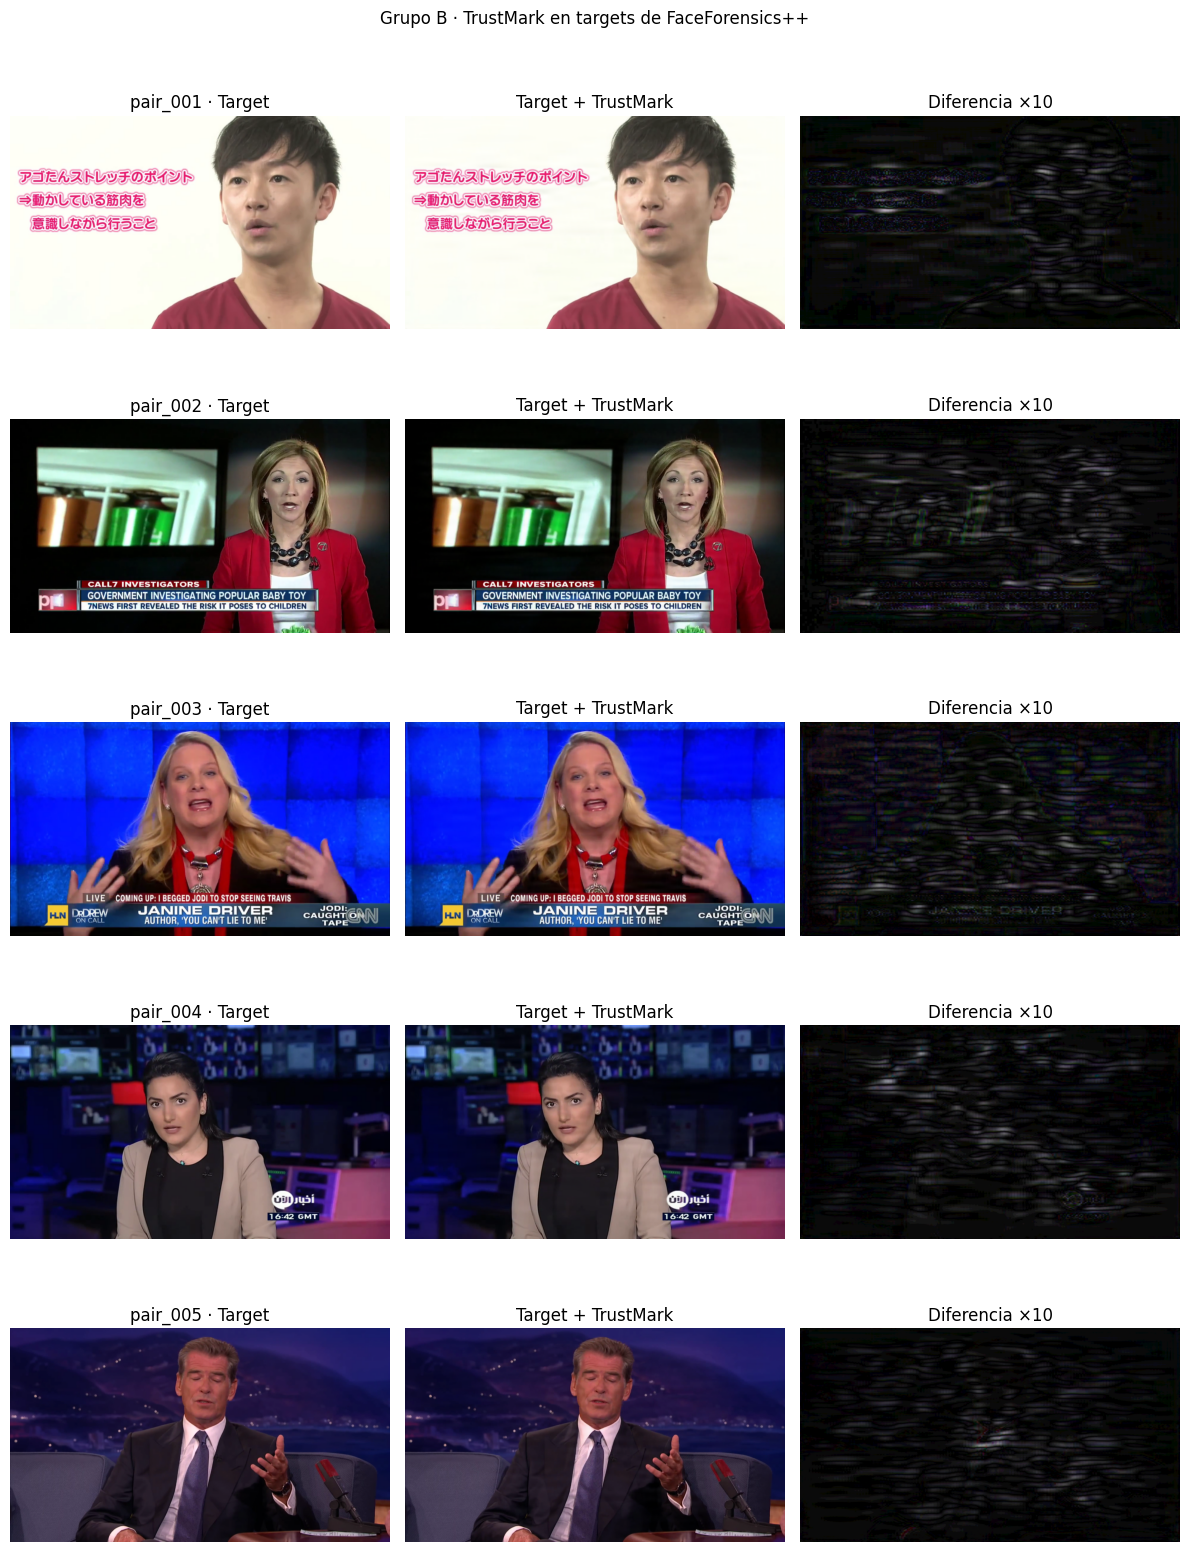

Figura: /content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026/figures/grupo_B/trustmark_targets/targets_trustmark_comparison.png


In [ ]:
# ============================================================
# CELDA 12 — Comparación visual del watermark
# Visualiza para cada target la imagen original, la imagen con
# TrustMark y una versión amplificada de la diferencia entre
# ambas para observar dónde se producen las modificaciones.
# La amplificación se utiliza únicamente para visualización.
# ============================================================
n = len(manifest)
fig, axes = plt.subplots(n, 3, figsize=(12, 3.2*n))
if n == 1:
    axes = np.array([axes])

for i, row in manifest.iterrows():
    with Image.open(row["target_original"]) as img:
        original = np.asarray(img.convert("RGB"), dtype=np.uint8)
    with Image.open(row["target_watermarked"]) as img:
        marked = np.asarray(img.convert("RGB"), dtype=np.uint8)

    diff = np.abs(marked.astype(np.int16) - original.astype(np.int16))
    diff_vis = np.clip(diff * 10, 0, 255).astype(np.uint8)

    axes[i,0].imshow(original)
    axes[i,0].set_title(f"{row['pair_id']} · Target")
    axes[i,1].imshow(marked)
    axes[i,1].set_title("Target + TrustMark")
    axes[i,2].imshow(diff_vis)
    axes[i,2].set_title("Diferencia ×10")

    for j in range(3):
        axes[i,j].axis("off")

plt.suptitle("Grupo B · TrustMark en targets de FaceForensics++", y=1.002)
plt.tight_layout()
plt.savefig(FIG_COMPARISON, dpi=180, bbox_inches="tight")
plt.show()

print("Figura:", FIG_COMPARISON)


In [ ]:
# ============================================================
# CELDA 13 — Resumen final de B01
# Presenta las métricas principales del experimento y confirma
# que los targets marcados están preparados para la siguiente
# etapa:
#
# target marcado + source → face swap
# ============================================================
print("============================================================")
print(" B01 COMPLETADO")
print("============================================================")
print(f"Targets procesados:      {len(metrics)}")
print(f"Detection rate:          {metrics['watermark_present'].mean():.3f}")
print(f"Exact recovery rate:     {metrics['exact_recovery'].mean():.3f}")
print(f"Bit accuracy detectada:  {metrics['bit_accuracy_detected'].mean():.3f}")
print(f"PSNR promedio:           {metrics['psnr'].mean():.2f} dB")
print(f"SSIM promedio:           {metrics['ssim'].mean():.4f}")
print()
print("Entrada preparada para B02:")
print("target marcado + source → face swap")


 B01 COMPLETADO
Targets procesados:      5
Detection rate:          1.000
Exact recovery rate:     1.000
Bit accuracy detectada:  1.000
PSNR promedio:           43.01 dB
SSIM promedio:           0.9859

Entrada preparada para B02:
target marcado + source → face swap
